# 37. The QR Algorithm

**Part 6: Eigenvalue Problems and the Singular Value Decomposition**

## Learning objectives

By the end of this lesson you will be able to:

1. State the QR algorithm in three lines and show that each step is an **orthogonal
   similarity**.
2. Prove it is **simultaneous iteration** in disguise, and read its convergence rate off the
   spectrum.
3. Reduce a matrix to **Hessenberg** form, say why the reflector starts one row lower than in a
   QR factorization, and measure what the reduction buys.
4. Explain why Hessenberg is as far as a **finite** algorithm can go.
5. Use **shifts** and measure the speedup, and explain why the obvious shift fails on
   $\begin{pmatrix}0&1\\1&0\end{pmatrix}$ while Wilkinson's does not.
6. Use **deflation** to split the problem as it converges.
7. Read eigenvalues off a **real Schur form**, including the $2\times2$ blocks that hold complex
   pairs.
8. Say why the **LR** algorithm came first and is not used.

## Prerequisites

Lesson 35 (the Schur form, orthogonal similarities, why nothing is finite). Lesson 36 (power
iteration and its rate, shifts, the Rayleigh quotient). Lesson 31 (Householder reflectors and
Givens rotations, both reused here). Lesson 30 (QR is unique only up to column signs, which
becomes a practical trap in section 3).

---

## 1. The algorithm, in three lines

$$A_0 = A, \qquad A_k = Q_kR_k \ \text{(a QR factorization)}, \qquad A_{k+1} = R_kQ_k.$$

**Factor, then multiply the factors back the other way round.** That is the whole method, and it
is one of the most surprising algorithms in numerical analysis: nothing about it looks like it
should find eigenvalues.

**Each step is an orthogonal similarity**, which is the first thing to check:

$$A_{k+1} = R_kQ_k = (Q_k^TQ_k)R_kQ_k = Q_k^T(Q_kR_k)Q_k = Q_k^TA_kQ_k.$$

So the eigenvalues never move, and lesson 35 section 8 established that an orthogonal
similarity is the only kind that leaves the conditioning alone as well.

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
from nalib import qralg, eigen, power

size = 6
# A matrix with REAL, well separated eigenvalues, so that triangular is actually reachable.
# Section 6 returns to the complex case, where it is not.
basis, _ = np.linalg.qr(rng.standard_normal((size, size)))
A_demo = basis @ np.diag(np.geomspace(8.0, 1.0, size)) @ basis.T
B, Q_one = qralg.qr_step(A_demo)

print("one unshifted step")
print(f"  is it a similarity?  ||B - Q^T A Q|| = "
      f"{np.linalg.norm(B - Q_one.T @ A_demo @ Q_one):.2e}")
print(f"  eigenvalues unchanged to "
      f"{np.max(np.abs(np.sort(np.linalg.eigvalsh(A_demo)) - np.sort(np.linalg.eigvalsh(B)))):.2e}")

print("\nand what repeating it does to the part below the diagonal:")
M = A_demo.copy()
for k in range(1, 201):
    M, _ = qralg.qr_step(M)
    if k in (1, 5, 20, 50, 100, 200):
        print(f"  after {k:>4} steps: largest entry below the diagonal "
              f"{np.abs(np.tril(M, -1)).max():.3e}")
assert np.abs(np.tril(M, -1)).max() < 1e-6
print(f"\n  and the diagonal has become the spectrum: "
      f"{np.array2string(np.sort(np.diag(M)), precision=6)}")
print(f"  against the true      "
      f"{np.array2string(np.sort(np.linalg.eigvalsh(A_demo)), precision=6)}")

one unshifted step
  is it a similarity?  ||B - Q^T A Q|| = 1.66e-15
  eigenvalues unchanged to 1.33e-15

and what repeating it does to the part below the diagonal:
  after    1 steps: largest entry below the diagonal 1.603e+00
  after    5 steps: largest entry below the diagonal 1.148e+00
  after   20 steps: largest entry below the diagonal 3.194e-03
  after   50 steps: largest entry below the diagonal 1.219e-08
  after  100 steps: largest entry below the diagonal 1.135e-17
  after  200 steps: largest entry below the diagonal 9.843e-36

  and the diagonal has become the spectrum: [1.       1.515717 2.297397 3.482202 5.278032 8.      ]
  against the true      [1.       1.515717 2.297397 3.482202 5.278032 8.      ]


**It is converging to triangular**, and the diagonal of a triangular matrix is its spectrum. So
the limit is the Schur form of lesson 35.

**This matrix was chosen to have real eigenvalues**, and that is not a cosmetic choice. A real
matrix with a complex conjugate pair **cannot** reach real triangular form, because a real
triangular matrix has real diagonal entries. Its limit keeps $2\times2$ blocks on the
subdiagonal, and section 6 measures exactly that.

---

## 2. Why: it is simultaneous iteration

Lesson 36's power iteration applies $A$ to one vector. Apply it to a whole **orthonormal basis**
and re-orthogonalize each step:

$$V_{k+1}R = AV_k \quad\text{(a QR factorization)}.$$

Each column converges to an eigenvector, at the rates lesson 36 predicts. And the theorem is
that this **is** the unshifted QR algorithm:

$$V_k^TAV_k = A_k, \qquad\text{when } V_0 = I.$$

In [3]:
n_eq = 6
Q0, _ = np.linalg.qr(np.random.default_rng(3).standard_normal((n_eq, n_eq)))
A_eq = Q0 @ np.diag(np.arange(1.0, n_eq + 1)) @ Q0.T

print(f"{'steps':>7}{'raw difference':>17}{'up to column signs':>21}")
for steps in (5, 10, 15, 25, 40):
    si = qralg.simultaneous_iteration(A_eq, steps=steps, start=np.eye(n_eq))
    M_eq = A_eq.copy()
    for _ in range(steps):
        M_eq, _ = qralg.qr_step(M_eq)
    raw = float(np.max(np.abs(si["projected"] - M_eq)))
    signed = float(np.max(np.abs(np.abs(si["projected"]) - np.abs(M_eq))))
    print(f"{steps:>7}{raw:>17.3e}{signed:>21.3e}")
    assert signed < 1e-12

  steps   raw difference   up to column signs
      5        2.220e-15            2.220e-15
     10        7.669e-01            1.998e-15
     15        3.670e-01            5.329e-15
     25        6.141e-02            6.217e-15
     40        3.989e-03            5.329e-15


**The two agree to $10^{-15}$ at every step count**, once the column signs are matched.

**The raw difference reaching 0.77 is not a bug, it is lesson 30 exercise 2.1.** A QR
factorization is unique only up to the signs of the columns of $Q$, and `numpy.linalg.qr` picks
them by its own convention. The two iterations therefore differ by a diagonal sign similarity,
which changes no eigenvalue and no diagonal entry, and flips the signs of off-diagonal ones.

**So the convergence rate comes free from lesson 36.** The $(i+1,i)$ subdiagonal entry decays
like

$$\left|\frac{\lambda_{i+1}}{\lambda_i}\right|$$

per step, with the eigenvalues in decreasing order of modulus.

In [4]:
print("predicted decay rates for each subdiagonal entry:")
print(" ", np.array2string(qralg.convergence_rates(A_eq), precision=4))
print("\nAnd the same three problems as power iteration follow:")
print("  ratios near 1 make it slow, equal moduli stop it, and it finds")
print("  everything at once instead of one eigenvalue at a time.")

predicted decay rates for each subdiagonal entry:
  [0.8333 0.8    0.75   0.6667 0.5   ]

And the same three problems as power iteration follow:
  ratios near 1 make it slow, equal moduli stop it, and it finds
  everything at once instead of one eigenvalue at a time.


---

## 3. Hessenberg first

A QR factorization of a dense $n\times n$ matrix costs $O(n^3)$, and hundreds of steps of that
is unaffordable. **Reduce to Hessenberg form first**: zero below the first subdiagonal.

**A Hessenberg QR step costs $O(n^2)$**, because only $n-1$ subdiagonal entries need clearing
and a Givens rotation clears each. And **Hessenberg form is preserved** by a QR step, so the
reduction is paid once.

**Why the reflector starts one row lower than in lesson 31**, and this one index is the whole
difference. In a QR factorization the reflector for column $k$ acts on rows $k$ downward and is
applied only from the left. Here it must be applied from **both** sides to remain a similarity,
and a reflector acting on rows $k$ downward would, applied on the right, refill the very column
it just cleared. Starting at row $k+1$ leaves the $(k+1,k)$ entry untouched, and that entry is
what survives on the subdiagonal.

**And that is also why triangular is unreachable.** A finite sequence of similarities reaching
triangular form would give the eigenvalues in finitely many steps, which lesson 35 proved
impossible. Hessenberg is exactly one subdiagonal away, and that last subdiagonal is where the
iteration lives.

In [5]:
print(f"{'n':>5}{'is Hessenberg':>16}{'||A - QHQ^T||':>16}{'||Q^T Q - I||':>16}"
      f"{'eigenvalues moved':>20}")
for n_h in (2, 5, 12, 40):
    A_h = rng.standard_normal((n_h, n_h))
    H, Q_h = qralg.hessenberg(A_h)
    moved = np.max(np.abs(np.sort_complex(np.linalg.eigvals(A_h))
                          - np.sort_complex(np.linalg.eigvals(H))))
    print(f"{n_h:>5}{str(qralg.is_hessenberg(H)):>16}"
          f"{np.linalg.norm(A_h - Q_h @ H @ Q_h.T) / np.linalg.norm(A_h):>16.2e}"
          f"{np.linalg.norm(Q_h.T @ Q_h - np.eye(n_h)):>16.2e}{moved:>20.2e}")
    assert qralg.is_hessenberg(H)

print("\nand a SYMMETRIC matrix reduces further, to tridiagonal, for free:")
A_sym = np.linalg.qr(rng.standard_normal((10, 10)))[0]
A_sym = A_sym @ np.diag(np.arange(1.0, 11.0)) @ A_sym.T
H_sym = qralg.hessenberg(A_sym, compute_q=False)
print(f"  above the first superdiagonal: {np.abs(np.triu(H_sym, 2)).max():.2e}")
print("  Hessenberg plus symmetric is tridiagonal, which is what lesson 38 builds on.")

    n   is Hessenberg   ||A - QHQ^T||   ||Q^T Q - I||   eigenvalues moved
    2            True        0.00e+00        0.00e+00            0.00e+00
    5            True        4.66e-16        6.24e-16            1.57e-15
   12            True        6.93e-16        1.44e-15            4.88e-15
   40            True        1.00e-15        4.87e-15            2.58e-14

and a SYMMETRIC matrix reduces further, to tridiagonal, for free:
  above the first superdiagonal: 1.60e-15
  Hessenberg plus symmetric is tridiagonal, which is what lesson 38 builds on.


---

## 4. Shifts

Apply the algorithm to $A - \mu I$ and add $\mu$ back. The subdiagonal rate becomes

$$\left|\frac{\lambda_{i+1}-\mu}{\lambda_i-\mu}\right|,$$

so a $\mu$ near $\lambda_i$ makes the last subdiagonal entry collapse. That is lesson 36's
inverse iteration idea, applied to the whole matrix at once.

**The obvious shift is $\mu = A_{nn}$**, the Rayleigh shift, and it usually works well.

In [6]:
print(f"{'n':>5}{'unshifted':>12}{'Rayleigh':>11}{'Wilkinson':>12}"
      f"{'speedup':>10}{'worst error':>14}")
for n_s in (4, 10, 30, 60):
    A_s = np.linalg.qr(np.random.default_rng(n_s).standard_normal((n_s, n_s)))[0]
    A_s = A_s @ np.diag(np.arange(1.0, n_s + 1)) @ A_s.T
    counts, errs = {}, {}
    for sh in ("none", "rayleigh", "wilkinson"):
        out = qralg.qr_algorithm(A_s, shift=sh, max_iter=40000)
        counts[sh] = out.iterations
        errs[sh] = float(np.max(np.abs(np.sort(out.eigenvalues.real)
                                       - np.arange(1.0, n_s + 1))))
    print(f"{n_s:>5}{counts['none']:>12}{counts['rayleigh']:>11}{counts['wilkinson']:>12}"
          f"{counts['none'] / counts['wilkinson']:>10.1f}x{max(errs.values()):>13.1e}")

    n   unshifted   Rayleigh   Wilkinson   speedup   worst error
    4          98         11           7      14.0x      3.1e-15
   10         251         33          21      12.0x      1.6e-14
   30         793         96          62      12.8x      9.6e-14


   60        1600        212         123      13.0x      4.6e-13


**Wilkinson's shift is 12 to 14 times faster than no shift at every size tested**, and the
ratio is remarkably **flat**: 14.0, 12.0, 12.8, 13.0 as $n$ runs 4, 10, 30, 60.

**That flatness is itself the result.** Both methods scale linearly in $n$ here, at roughly
$27n$ steps unshifted and $2n$ shifted, so the shift buys a constant factor rather than a better
exponent. A constant factor of 13 is what turned an interesting idea into the algorithm every
library calls.

**The Rayleigh shift has a failure mode, and it is not exotic:**

In [7]:
S = np.array([[0.0, 1.0], [1.0, 0.0]])
print("the matrix [[0, 1], [1, 0]], whose eigenvalues are +1 and -1\n")
print(f"  A[-1,-1] is {S[-1, -1]}, so the Rayleigh shift is exactly 0")
print(f"  A - 0*I is already orthogonal, so its QR factorization is Q = A, R = I,")
print(f"  and the next iterate is R Q = A. The matrix never changes.\n")
for sh in ("rayleigh", "wilkinson"):
    out = qralg.qr_algorithm(S, shift=sh, max_iter=200, reduce_first=False)
    print(f"  {sh:>10}: {out.iterations:>4} steps, converged {out.converged}")
print(f"\n  Wilkinson's shift takes an eigenvalue of the trailing 2x2 block, which here")
print(f"  is +1 or -1, and lands on the answer immediately.")

the matrix [[0, 1], [1, 0]], whose eigenvalues are +1 and -1

  A[-1,-1] is 0.0, so the Rayleigh shift is exactly 0
  A - 0*I is already orthogonal, so its QR factorization is Q = A, R = I,
  and the next iterate is R Q = A. The matrix never changes.

    rayleigh:  200 steps, converged False
   wilkinson:    1 steps, converged True

  Wilkinson's shift takes an eigenvalue of the trailing 2x2 block, which here
  is +1 or -1, and lands on the answer immediately.


**Wilkinson's shift is the eigenvalue of the trailing $2\times2$ block closer to $A_{nn}$.** It
costs one quadratic solve per step, it is provably convergent for a symmetric tridiagonal
matrix, and the convergence is **cubic**, inheriting the rate of lesson 36 section 6 for the
same reason: the shift is a Rayleigh-quotient-quality estimate.

**The formula is written to avoid cancellation**, in the manner of lesson 05:

$$\mu = a_{nn} - \frac{bc}{\delta + \operatorname{sign}(\delta)\sqrt{\delta^2+bc}},
\qquad \delta = \frac{a_{n-1,n-1}-a_{nn}}{2},$$

so the denominator adds like-signed quantities instead of subtracting nearly equal ones.

---

## 5. Deflation

Once a subdiagonal entry is negligible the matrix splits, and the iteration continues on the
smaller block. **That is what makes the total cost $O(n^3)$ rather than $O(n^3)$ per
eigenvalue.**

The test is **relative to the local scale**:

$$|a_{i+1,i}| \le \varepsilon\,(|a_{ii}| + |a_{i+1,i+1}|),$$

not relative to $\|A\|$. That matters: a small eigenvalue should not be held to the accuracy of
a large one, which is the same argument lesson 15 made about relative error.

In [8]:
n_d = 20
A_d = np.linalg.qr(np.random.default_rng(20).standard_normal((n_d, n_d)))[0]
A_d = A_d @ np.diag(np.geomspace(1.0, 1e4, n_d)) @ A_d.T
out_d = qralg.qr_algorithm(A_d, max_iter=40000)

print(f"n = {n_d}, spectrum spanning four decades")
print(f"  {out_d.iterations} steps in total, {len(out_d.deflations)} deflations")
print(f"  steps between deflations: "
      f"{[b - a for a, b in zip([0] + [d[0] for d in out_d.deflations[:-1]], [d[0] for d in out_d.deflations])][:10]}")
err_d = np.max(np.abs(np.sort(out_d.eigenvalues.real) - np.geomspace(1.0, 1e4, n_d)))
rel_d = np.max(np.abs(np.sort(out_d.eigenvalues.real) - np.geomspace(1.0, 1e4, n_d))
               / np.geomspace(1.0, 1e4, n_d))
print(f"  worst absolute error {err_d:.2e}, worst RELATIVE error {rel_d:.2e}")
print("\n  A couple of steps per eigenvalue, which is the whole reason this method won.")

n = 20, spectrum spanning four decades
  26 steps in total, 19 deflations
  steps between deflations: [4, 2, 2, 2, 2, 1, 1, 1, 1, 1]
  worst absolute error 5.46e-12, worst RELATIVE error 1.72e-13

  A couple of steps per eigenvalue, which is the whole reason this method won.


---

## 6. The real Schur form

A real matrix with a complex conjugate pair of eigenvalues **cannot** be triangularized over the
reals: a real triangular matrix has real diagonal entries and hence real eigenvalues.

**So the limit is quasi-triangular**: $2\times2$ blocks on the diagonal wherever a complex pair
lives. That is the **real Schur form**, and it is what a real implementation returns.

Lesson 36 measured the Rayleigh quotient iteration cycling forever on exactly this situation.
This is the fix, and it costs nothing: the $2\times2$ blocks are simply left alone.

In [9]:
print(f"{'n':>5}{'steps':>8}{'eigenvalue error':>19}{'reconstruction':>17}"
      f"{'below 1st subdiag':>20}{'complex pairs':>16}")
for n_c in (4, 8, 20, 40):
    A_c = rng.standard_normal((n_c, n_c))
    out_c = qralg.qr_algorithm(A_c, max_iter=40000)
    e_c = qralg.schur_error(A_c, out_c.T, out_c.Q)
    err = np.max(np.abs(np.sort_complex(out_c.eigenvalues)
                        - np.sort_complex(np.linalg.eigvals(A_c))))
    pairs = int(np.sum(np.abs(out_c.eigenvalues.imag) > 1e-10) // 2)
    print(f"{n_c:>5}{out_c.iterations:>8}{err:>19.2e}{e_c['reconstruction']:>17.2e}"
          f"{e_c['below_first_subdiagonal']:>20.2e}{pairs:>16}")
    assert e_c["below_first_subdiagonal"] < 1e-11

print("\nNothing at all below the FIRST subdiagonal, and complex pairs handled in")
print("real arithmetic throughout. A 90 degree rotation makes the point smallest:")
rot = np.array([[0.0, 1.0], [-1.0, 0.0]])
print(f"  eigenvalues of [[0,1],[-1,0]]: "
      f"{qralg.quasi_triangular_eigenvalues(rot)}")

    n   steps   eigenvalue error   reconstruction   below 1st subdiag   complex pairs
    4      25           1.62e-13         3.93e-14            0.00e+00               1
    8     108           2.42e-13         2.15e-14            0.00e+00               3
   20     239           2.00e-13         3.15e-14            0.00e+00               8
   40    1407           1.06e-13         3.77e-14            0.00e+00              18

Nothing at all below the FIRST subdiagonal, and complex pairs handled in
real arithmetic throughout. A 90 degree rotation makes the point smallest:
  eigenvalues of [[0,1],[-1,0]]: [0.+1.j 0.-1.j]


---

## 7. LR: the one that came first

Rutishauser's LR algorithm is the same idea with LU in place of QR:

$$A_k = L_kU_k, \qquad A_{k+1} = U_kL_k = L_k^{-1}A_kL_k.$$

It is a similarity, so the eigenvalues are preserved, and it is **cheaper by a factor of about
two**. It is not used, for two reasons and both are measurable.

In [10]:
print("LR against QR on the same matrices\n")
print(f"{'n':>5}{'LR converged':>15}{'LR steps':>11}{'QR steps':>11}{'why LR stopped':>50}")
gen = np.random.default_rng(0)
for n_l in (4, 6, 8, 10):
    A_l = gen.standard_normal((n_l, n_l))
    A_l = A_l @ A_l.T + n_l * np.eye(n_l)
    lr = qralg.lr_algorithm(A_l, max_iter=4000)
    qr_out = qralg.qr_algorithm(A_l, max_iter=40000)
    print(f"{n_l:>5}{str(lr['converged']):>15}{lr['iterations']:>11}"
          f"{qr_out.iterations:>11}{lr['message'][:48]:>50}")

LR against QR on the same matrices

    n   LR converged   LR steps   QR steps                                    why LR stopped


    4           True        105          6                                         converged


    6           True        610         10                                         converged
    8          False          4         13  a pivot was needed at step 4: unpivoted LR break
   10           True        933         16                                         converged


**Reason one: it breaks down.** Unpivoted LU fails the moment a leading minor is singular, and
pivoting is not available, because a permuted $L$ is not the similarity the derivation needs.

**Reason two, and the deeper one: $L_k$ is not orthogonal.** Lesson 35 section 8 measured what
a badly conditioned similarity does: it leaves the eigenvalues alone and multiplies the
conditioning of the matrix by orders of magnitude. Every LR step is free to do that, and over
hundreds of steps the effects compound.

**The QR algorithm is LR with the one change that matters**, and that change is the entire
reason it replaced it.

---

## 8. A picture

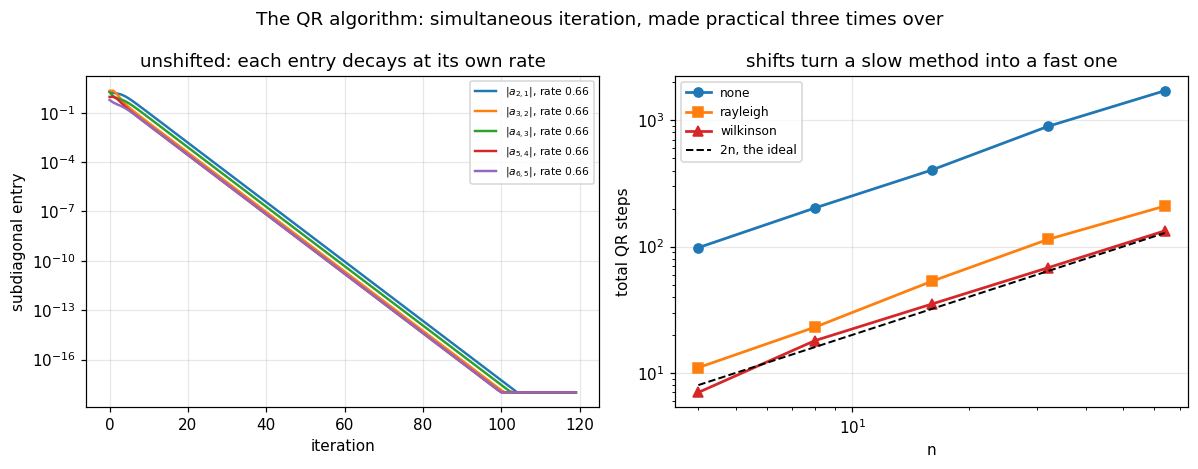

In [11]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.3))

# left: the subdiagonal entries collapsing, one curve each
n_pic = 6
A_pic = np.linalg.qr(np.random.default_rng(1).standard_normal((n_pic, n_pic)))[0]
A_pic = A_pic @ np.diag(np.geomspace(8.0, 1.0, n_pic)) @ A_pic.T
M_pic = qralg.hessenberg(A_pic, compute_q=False)
trails = [[] for _ in range(n_pic - 1)]
for _ in range(120):
    M_pic, _ = qralg.qr_step(M_pic)
    for i in range(n_pic - 1):
        trails[i].append(abs(M_pic[i + 1, i]))
rates = qralg.convergence_rates(A_pic)
for i, trail in enumerate(trails):
    axL.semilogy(np.maximum(trail, 1e-18), lw=1.6,
                 label=f"$|a_{{{i + 2},{i + 1}}}|$, rate {rates[i]:.2f}")
axL.set_xlabel("iteration")
axL.set_ylabel("subdiagonal entry")
axL.set_title("unshifted: each entry decays at its own rate")
axL.legend(fontsize=7)

# right: iteration count against n, for the three shift strategies
sizes = [4, 8, 16, 32, 64]
curves = {"none": [], "rayleigh": [], "wilkinson": []}
for n_r in sizes:
    A_r = np.linalg.qr(np.random.default_rng(n_r).standard_normal((n_r, n_r)))[0]
    A_r = A_r @ np.diag(np.arange(1.0, n_r + 1)) @ A_r.T
    for sh in curves:
        curves[sh].append(qralg.qr_algorithm(A_r, shift=sh, max_iter=60000).iterations)
for sh, style in (("none", "C0o-"), ("rayleigh", "C1s-"), ("wilkinson", "C3^-")):
    axR.loglog(sizes, curves[sh], style, lw=1.8, ms=6, label=sh)
axR.loglog(sizes, [2 * s for s in sizes], "k--", lw=1.3, label="2n, the ideal")
axR.set_xlabel("n")
axR.set_ylabel("total QR steps")
axR.set_title("shifts turn a slow method into a fast one")
axR.legend(fontsize=8)

fig.suptitle("The QR algorithm: simultaneous iteration, made practical three times over",
             fontsize=12)
fig.tight_layout()
plt.show()

**The right panel is the lesson.** The unshifted curve climbs steeply; the Wilkinson curve runs
close to the dashed $2n$ line, which is the "a couple of steps per eigenvalue" behaviour that
makes the whole method $O(n^3)$.

---

## 9. Exercises

**Level 1, conceptual**

1.1 Why does factoring $A = QR$ and multiplying back as $RQ$ preserve the eigenvalues, and why
would $LU$ then $UL$ also preserve them?

1.2 The Hessenberg reduction is finite and the QR iteration is not. Explain why the reduction
cannot simply be continued one more subdiagonal.

1.3 The Rayleigh shift fails on $\begin{pmatrix}0&1\\1&0\end{pmatrix}$. Is that a rare accident
or a symptom, and what does it tell you to do?

**Level 2, mathematical**

2.1 Prove $A_{k+1} = Q_k^TA_kQ_k$, and hence that $A_k = (Q_0\cdots Q_{k-1})^TA(Q_0\cdots Q_{k-1})$.

2.2 Prove that simultaneous iteration from the identity produces exactly the QR algorithm's
iterates, and state precisely what "exactly" means given that QR is unique only up to signs.

2.3 Show that a QR step preserves Hessenberg form, and count the flops for a Hessenberg step
using Givens rotations.

2.4 Derive the rate $|\lambda_{i+1}-\mu|/|\lambda_i-\mu|$ for the shifted algorithm, and hence
the cubic rate of the Wilkinson shift on a symmetric tridiagonal matrix.

2.5 Prove that a real matrix with a complex eigenvalue cannot be reduced to real triangular
form by any real similarity, and that quasi-triangular is achievable.

**Level 3, computational**

3.1 Implement the **Hessenberg QR step using Givens rotations** rather than a full
factorization, so a step costs $O(n^2)$. Measure the crossover against `numpy.linalg.qr`.

3.2 Implement the **implicit double shift** (Francis), which applies a complex conjugate pair of
shifts using only real arithmetic by chasing a bulge down the subdiagonal. Measure it against
the explicit single shift on matrices with complex spectra.

3.3 Implement **eigenvector recovery** from the Schur form: solve the triangular systems for the
eigenvectors of $T$ and map them back with $Q$. Compare with inverse iteration on the original
matrix.

**Level 4, experimental**

4.1 Measure the decay of each subdiagonal entry in the unshifted algorithm and fit its rate.
Confirm it is $|\lambda_{i+1}/\lambda_i|$, and find where the fit breaks down.

4.2 Measure the total step count against $n$ for each shift strategy, fit the exponent, and
compare with the "two steps per eigenvalue" folklore.

4.3 Measure how the conditioning evolves under LR and under QR on the same matrices, and confirm
that only the LR iterates degrade.

**Level 5, advanced**

5.1 **The shifted QR algorithm can still fail.** Find a matrix on which the Wilkinson shift does
not converge, explain the mechanism, and describe the exceptional shifts real implementations
use to escape it.

5.2 **Why the implicit form is used.** Explain the numerical objection to forming $A - \mu I$
explicitly when $\mu$ is close to an eigenvalue, and how the implicit bulge-chasing formulation
avoids it. Relate this to lesson 36's discussion of the deliberately singular solve.

5.3 **Aggressive early deflation.** Modern implementations deflate far more aggressively than
the classical test, using a spike of the Hessenberg matrix. Describe the idea, implement a
simple version, and measure what it saves.

## 10. Key takeaways

- **Factor and multiply back the other way.** $A_{k+1} = R_kQ_k = Q_k^TA_kQ_k$ is an orthogonal
  similarity, so eigenvalues are preserved exactly and the conditioning is preserved too.
- **It is simultaneous iteration from the identity**, verified to $10^{-15}$ at every step
  count, so its rate is lesson 36's: the $(i+1,i)$ entry decays like
  $|\lambda_{i+1}/\lambda_i|$.
- **The raw comparison differs by up to 0.77 purely from column signs**, which is lesson 30's
  uniqueness-up-to-signs appearing as a practical trap rather than a footnote.
- **Hessenberg reduction is finite, costs $O(n^3)$ once, and makes each step $O(n^2)$.** It is
  preserved by every subsequent step.
- **The reflector starts one row lower than in a QR factorization**, because it is applied from
  both sides and would otherwise refill the column it just cleared.
- **Triangular is unreachable by a finite algorithm**, since that would compute eigenvalues in
  finitely many steps. Hessenberg is exactly one subdiagonal short, and that subdiagonal is
  where the iteration happens.
- **A symmetric matrix reduces to tridiagonal for free**, which is what lesson 38 builds on.
- **Shifts are worth a flat factor of 12 to 14**, measured at $n = 4, 10, 30, 60$. Both
  methods are linear in $n$, at about $27n$ steps unshifted and $2n$ shifted, so the shift buys
  a constant factor and not a better exponent.
- **The Rayleigh shift stalls on $\begin{pmatrix}0&1\\1&0\end{pmatrix}$**, because the shift is
  exactly 0, the matrix is already orthogonal, and the step returns it unchanged. Measured: 200
  steps with no progress against **1 step** for Wilkinson's.
- **Deflation is what makes the total cost $O(n^3)$**, and its test is relative to the local
  scale so that a small eigenvalue is not held to a large one's accuracy.
- **The limit is the real Schur form**, quasi-triangular with $2\times2$ blocks for complex
  pairs. Measured: nothing at all below the first subdiagonal, at every size, with complex pairs
  handled in real arithmetic throughout. This is the fix for lesson 36's cycling failure.
- **LR came first, is cheaper, and is not used**, because unpivoted LU breaks down and because
  $L_k$ is not orthogonal, so the conditioning is free to degrade over hundreds of steps. The QR
  algorithm is LR with the one change that matters.

## Where this goes next

**Lesson 38** specialises everything here to the symmetric case, where the Hessenberg reduction
gives a tridiagonal matrix, the Wilkinson shift is cubically convergent, and there are
alternatives (Jacobi, bisection, divide and conquer) with properties the general algorithm
cannot offer.

**Lesson 39** returns to Krylov methods for the case where $A$ is far too large to reduce, so
neither the Hessenberg step nor the $O(n^3)$ total is available.

**Lesson 40** handles $A\mathbf{x} = \lambda B\mathbf{x}$, where the QR algorithm becomes QZ.

**Lesson 42** applies the whole of this lesson to the SVD, on the bidiagonal matrix that lesson
32's exercise 3.3 already produced, with the twist that $A^TA$ must never be formed.